# demos.qcheb_gnn.ipynb

This notebook demonstrates a Chebyshev-based graph neural network module built to be compatible with the existing `GraphInput`, classical Kipf–Welling GNN,
and `qgtheta` quantum-inspired architecture. We focus first on the non-diagonalizing direct recurrence implementation of
the Chebyshev filter,
$$
g_\theta(L)X = \sum_{k=0}^{K} \theta_k T_k(L)X,
$$
where the Chebyshev polynomials satisfy
$$
T_0(L)X = X,\qquad
T_1(L)X = LX,\qquad
T_k(L)X = 2LT_{k-1}(L)X - T_{k-2}(L)X.
$$

We can also compare this with a spectral debugging route based on exactceigendecomposition, which is useful as a validation path and as a design bridge
towards future diagonalization-based approaches such as sample-based quantum diagonalization (SQD). For the moment we focus on the same task shown in other demos: 
- build a small pandapower electrical network;
- generate multiple operating scenarios that are then converted to a `GraphInput` abstraction;
- train a two-layer quantum GNN build with the functionalities of `qcheb_gnn.py` and evaluate the model on held-out scenarios.

As in the other demos the learning task is a node-level regression: predict bus voltage magnitudes `vm_pu` from graph-structured electrical input features.

In [1]:
import os
os.chdir("..")

In [4]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandapower as pp
from scipy.optimize import minimize


In [16]:
from utils.graphs import build_graph_input
from utils.pandapower_adapter import pandapower_to_graph_bundle, bundle_to_graph_input, display_graph_signal_comparison, pandapower_to_graph_bundle
from classical_gnns.shallow_kipf_welling_gnn import relu, identity
from quantum_gnns.qcheb_gnn import *

## Utilities

In [6]:
def generate_voltage_dataset(base_net, n_samples=80, seed=42):
    """
    Generate node-level regression data on a fixed pandapower topology.

    Args:
        base_net: Base pandapower network.
        n_samples: Number of operating scenarios.
        seed: Random seed.

    Returns:
        X: Input array of shape (num_samples, num_nodes, 1).
        Y: Target array of shape (num_samples, num_nodes, 1).
    """
    rng = np.random.default_rng(seed)
    X_list = []
    Y_list = []

    for _ in range(n_samples):
        net = copy.deepcopy(base_net)

        for load_idx in net.load.index:
            p = rng.uniform(0.2, 1.2)
            q = 0.2 * p
            net.load.loc[load_idx, "p_mw"] = p
            net.load.loc[load_idx, "q_mvar"] = q

        pp.runpp(net)

        node_order = list(map(int, net.bus.index))

        x = np.zeros((len(node_order), 1), dtype=np.float64)
        for _, row in net.load.iterrows():
            bus_idx = int(row["bus"])
            x[bus_idx, 0] += float(row["p_mw"])

        y = (
            net.res_bus.loc[node_order, "vm_pu"]
            .to_numpy(dtype=np.float64)
            .reshape(-1, 1)
        )

        X_list.append(x)
        Y_list.append(y)

    X = np.stack(X_list, axis=0)
    Y = np.stack(Y_list, axis=0)
    return X, Y

In [11]:
def mse_loss(y_pred, y_true):
    """
    Mean squared error over all nodes and samples.
    """
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    return float(np.mean((y_pred - y_true) ** 2))


def predict_dataset(model, graph_input, X_data):
    """
    Predict a full dataset.

    Args:
        model: Graph model with forward(graph_input, features).
        graph_input: Fixed-topology GraphInput.
        X_data: Array of shape (num_samples, num_nodes, in_features).

    Returns:
        Array of shape (num_samples, num_nodes, out_features).
    """
    preds = []
    for i in range(X_data.shape[0]):
        preds.append(np.asarray(model.forward(graph_input, X_data[i]), dtype=float))
    return np.stack(preds, axis=0)

In [12]:
def pack_parameters(model):
    parts = [model.layer1.weight.reshape(-1),model.layer1.bias.reshape(-1),model.layer2.weight.reshape(-1),
             model.layer2.bias.reshape(-1),model.layer1.cheb_filter.theta.reshape(-1),model.layer2.cheb_filter.theta.reshape(-1),]
    return np.concatenate(parts)


def unpack_parameters(param_vector, model):
    param_vector = np.asarray(param_vector, dtype=float).reshape(-1)
    cursor = 0
    w1_shape = model.layer1.weight.shape
    b1_shape = model.layer1.bias.shape
    w2_shape = model.layer2.weight.shape
    b2_shape = model.layer2.bias.shape
    t1_shape = model.layer1.cheb_filter.theta.shape
    t2_shape = model.layer2.cheb_filter.theta.shape
    w1_size = int(np.prod(w1_shape))
    b1_size = int(np.prod(b1_shape))
    w2_size = int(np.prod(w2_shape))
    b2_size = int(np.prod(b2_shape))
    t1_size = int(np.prod(t1_shape))
    t2_size = int(np.prod(t2_shape))
    model.layer1.weight = param_vector[cursor:cursor + w1_size].reshape(w1_shape)
    cursor += w1_size
    model.layer1.bias = param_vector[cursor:cursor + b1_size].reshape(b1_shape)
    cursor += b1_size
    model.layer2.weight = param_vector[cursor:cursor + w2_size].reshape(w2_shape)
    cursor += w2_size
    model.layer2.bias = param_vector[cursor:cursor + b2_size].reshape(b2_shape)
    cursor += b2_size
    model.layer1.cheb_filter.theta = param_vector[cursor:cursor + t1_size].reshape(t1_shape)
    cursor += t1_size
    model.layer2.cheb_filter.theta = param_vector[cursor:cursor + t2_size].reshape(t2_shape)
    cursor += t2_size
    if cursor != param_vector.size:
        raise ValueError("Parameter vector size mismatch.")

## Test grid and dataset

In [7]:
base_net = pp.create_empty_network(sn_mva=100.0)
buses = [pp.create_bus(base_net, vn_kv=20.0, name=f"Bus {i}") for i in range(5)]
pp.create_ext_grid(base_net, bus=buses[0], vm_pu=1.0)
for b in buses[1:]:
    pp.create_load(base_net, bus=b, p_mw=0.5, q_mvar=0.1)

line_kwargs = dict(length_km=1.0,r_ohm_per_km=0.25,x_ohm_per_km=0.10,c_nf_per_km=10.0,max_i_ka=0.40,)
for i in range(4):
    pp.create_line_from_parameters(base_net,buses[i],buses[i + 1],**line_kwargs,)

X, Y = generate_voltage_dataset(base_net, n_samples=80, seed=42)

In [8]:
topology_bundle = pandapower_to_graph_bundle(base_net,node_feature_specs=["load_p_mw"],
                                             edge_feature_specs=["loading_percent"],run_powerflow=True,)
graph_input = bundle_to_graph_input(topology_bundle,build_graph_input_fn=build_graph_input,)
#print("X shape:", X.shape)
#print("Y shape:", Y.shape)
#print("Node order:", topology_bundle.node_order)

## Training and test

In [9]:
num_samples = X.shape[0]
num_train = int(0.75 * num_samples)
X_train = X[:num_train]
Y_train = Y[:num_train]
X_test = X[num_train:]
Y_test = Y[num_train:]
#print("X_train shape:", X_train.shape)
#print("Y_train shape:", Y_train.shape)
#print("X_test shape:", X_test.shape)
#print("Y_test shape:", Y_test.shape)

In [ ]:
in_features = X.shape[2]
hidden_features = 8
out_features = Y.shape[2]

first_filter = build_direct_cheb_filter(order=3,theta=np.array([1.0, 0.0, 0.0, 0.0], dtype=float),use_rescaled_laplacian=True,)
second_filter = build_direct_cheb_filter(order=2,theta=np.array([1.0, 0.0, 0.0], dtype=float),use_rescaled_laplacian=True,)

qcheb_net = TwoLayerQChebNetwork(in_features=in_features,hidden_features=hidden_features,out_features=out_features,
                                 first_filter=first_filter,second_filter=second_filter,hidden_activation=relu,
                                 output_activation=identity,random_state=7,)

#sample_pred = qcheb_net.forward(graph_input, X_train[0])
#print("Prediction shape:", sample_pred.shape)
#print(sample_pred)

In [13]:
initial_params = pack_parameters(qcheb_net)
#print("Number of trainable parameters:", initial_params.size)
train_history = []
def objective_function(param_vector):
    unpack_parameters(param_vector, qcheb_net)
    y_pred_train = predict_dataset(qcheb_net, graph_input, X_train)
    loss = mse_loss(y_pred_train, Y_train)
    train_history.append(loss)
    return loss

In [17]:
result = minimize(objective_function,x0=initial_params,method="Powell",options={"maxiter": 200,"disp": True,},)
best_params = result.x.copy()
unpack_parameters(best_params, qcheb_net)
print("Optimization success:", result.success)
print("Final training loss:", train_history[-1])
print("Optimizer message:", result.message)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 133
         Function evaluations: 29723
Optimization success: True
Final training loss: 1.1106576708508896e-07
Optimizer message: Optimization terminated successfully.


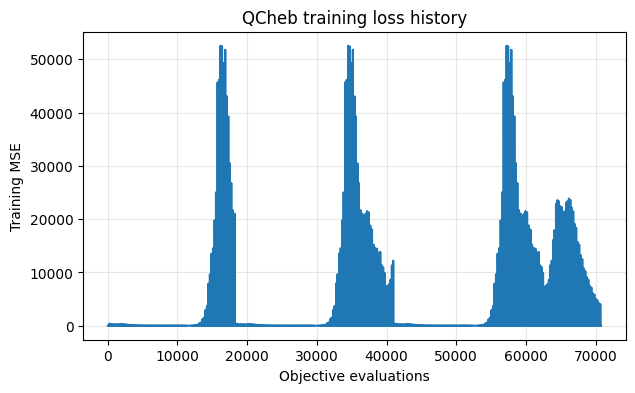

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(train_history)
plt.title("QCheb training loss history")
plt.xlabel("Objective evaluations")
plt.ylabel("Training MSE")
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
Y_pred_train = predict_dataset(qcheb_net, graph_input, X_train)
Y_pred_test = predict_dataset(qcheb_net, graph_input, X_test)
train_mse = mse_loss(Y_pred_train, Y_train)
test_mse = mse_loss(Y_pred_test, Y_test)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 1.110657663604197e-07
Test MSE: 1.1381105724724567e-07


## True vs predicted (one sample)

In [20]:
sample_idx = 0  
n_train = X_train.shape[0]
test_sample_global_idx = n_train + sample_idx
y_true = Y_test[sample_idx, :, 0]
y_pred = Y_pred_test[sample_idx, :, 0]
#print("Selected global sample index:", test_sample_global_idx)
#print("True vm_pu:")
#print(y_true)
#print("Predicted vm_pu:")
#print(y_pred)

In [21]:
display_net = copy.deepcopy(base_net)
sample_loads = X[test_sample_global_idx, :, 0]

for load_idx, bus_idx in zip(display_net.load.index,display_net.load["bus"].to_numpy(),):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(sample_loads[bus_idx])
    display_net.load.loc[load_idx, "p_mw"] = p
    display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p
pp.runpp(display_net)

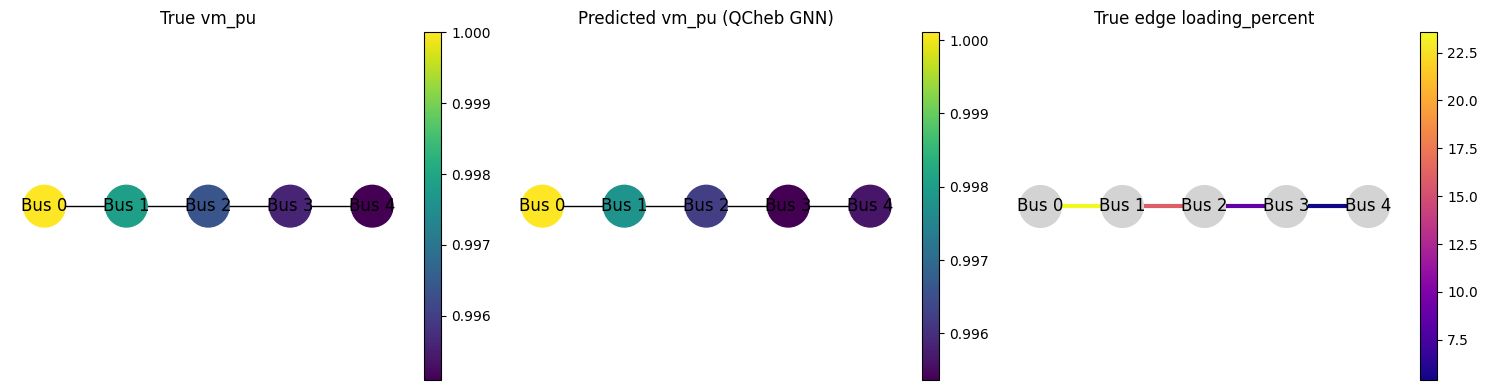

In [22]:
display_bundle = pandapower_to_graph_bundle(display_net,node_feature_specs=["load_p_mw"],edge_feature_specs=["loading_percent"],run_powerflow=True,)
edge_values = np.asarray([display_bundle.edge_features[tuple(sorted((u, v)))][0] for u, v in display_bundle.graph.edges()],dtype=float,)
display_graph_signal_comparison(G=display_bundle.graph,node_order=display_bundle.node_order,input_node_values=y_true,output_node_values=y_pred,
                                edge_values=edge_values,node_labels=display_bundle.node_labels,layout="line",input_title="True vm_pu",
                                output_title="Predicted vm_pu (QCheb GNN)",edge_title="True edge loading_percent",figsize=(15.0, 4.0),)

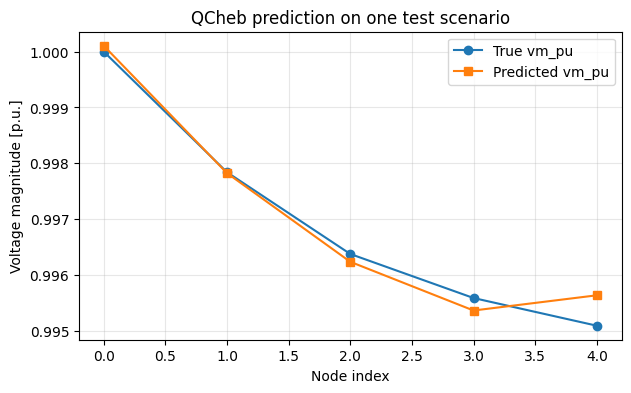

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(y_true, marker="o", label="True vm_pu")
plt.plot(y_pred, marker="s", label="Predicted vm_pu")
plt.title("QCheb prediction on one test scenario")
plt.xlabel("Node index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# Aggregated results over the entire test set
all_true = Y_test.reshape(-1)
all_pred = Y_pred_test.reshape(-1)
rmse = float(np.sqrt(np.mean((all_pred - all_true) ** 2)))
mae = float(np.mean(np.abs(all_pred - all_true)))
print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 0.00033735894422298285
Test MAE: 0.0002521664654807376
